<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# DATA/MSML 641: Natural Language Processing
## Lecture 5: Evaluation in NLP


**University of Maryland, College Park**  
**Spring 2026**  
**Instructor**: Armin Mehrabian  
**Date**: February 24–25, 2026  


In [1]:
# Imports and Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from scipy.stats import pearsonr

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# A. Evaluation Foundations
 


# Why Do We Evaluate NLP Systems?

### Motivation

• Modern NLP models are **impressively capable** — but what does “better” really mean?  
• A new model may have:
  - Lower training loss — but does that improve translation quality?  
  - Higher BLEU — but do humans prefer its outputs?  
  - Faster inference — but does it actually help users?  

### The Core Challenge
> **Evaluation defines progress.**  
> The way we measure determines *what we optimize* and *what we value*.

### Evaluation Answers Questions Like:
- Is my system *accurate* or *useful*?  
- Does it *generalize* or just *memorize*?  
- Is it *better* than existing systems — and by *how much*?  
- Does improvement on benchmarks reflect *real-world gains*?

### Takeaway
Before we can talk about *how* to evaluate,  
we must decide **what kind of progress we want to measure.**


# Types of Evaluations

• **Intrinsic** — How well does the algorithm do at its task?  
• **Extrinsic** — How well does it facilitate a larger task of which it is a component?  
• **Situated** — How well does it perform in a real-use setting?  
• **Economic** — What will people pay for it?

<sub>Adapted from: Sparck Jones & Galliers (1996), *Evaluating Natural Language Processing Systems*;  
Cohen & Howe (1988), *How Evaluation Guides AI Research*, *AI Magazine*.</sub>


# Example – Evaluating a Language Model

### 1. Intrinsic Evaluation
- How well does the model predict the next word in text?  
- Measured using **cross-entropy** or **perplexity** on a held-out corpus  
- Lower perplexity ⇒ better internal predictive performance  
- Example: GPT-2 trained on WikiText-103 achieves lower perplexity than an RNN LM

### 2. Extrinsic Evaluation
- How well does the model improve a **downstream task** that uses it?  
- Example: Using the same language model as an encoder in a **summarization** or **QA** system  
- Measured by **task-specific metrics** (e.g., ROUGE, F1, accuracy)  
- A lower-perplexity LM may not yield higher ROUGE or F1 — different evaluation goals

<div style="text-align:center; margin-top:10px;">
  <img src="img/validation_loss_vs_solve_rate.png" alt="Validation Score Vs. Solve Rate" style="max-width:80%; border:1px solid #ccc; margin:5px;">
  
</div>

Li, Yujia, et al. "Competition-level code generation with alphacode." Science 378.6624 (2022): 1092-1097.


## 3. Situated Evaluation

### What It Is
- Evaluates **real-world system behavior** under **actual use conditions**
- Focuses on how users interact with the system — not just how well it scores on a test set
- Captures performance drift, user adaptation, and contextual effects




### Situated Evaluation Example: Deployed Customer Support Chatbot

**Scenario:**  
A company fine-tunes a support chatbot on internal FAQs.  
Before deployment, it achieves 90% accuracy on test tickets (extrinsic eval).  
After deployment, they monitor real interactions for 3 months.

| Metric | Definition | Observed Result |
|---------|-------------|----------------|
| Task Success Rate | % of sessions resolved without human escalation | 72% |
| User Satisfaction | Avg. post-chat survey (1–5 scale) | 4.1 |
| Factual Error Rate | % of answers flagged by reviewers as incorrect | 11% |
| Response Latency | Average user wait time | 3.2s |
| Escalation Triggered | % of sessions requiring human handoff | 28% |

**Findings:**
- Accuracy (90%) didn’t translate to success rate (72%) due to real-world ambiguity.  
- Users asked multi-intent or emotional questions unseen in training.  
- Post-deployment retraining improved factuality and reduced escalation rate.

---

> Situated evaluation reveals *how systems actually behave with humans*,  
> uncovering failure modes invisible in lab benchmarks.


# 4. Economic Evaluation

### What It Is
- Measures **real-world value and adoption**, not just technical quality  
- Focuses on **cost–benefit tradeoffs** and **market willingness to pay**  
- Common in applied NLP, product, and API settings


### Economic Evaluation Example: Machine Translation API

**Scenario:**  
Two translation systems are compared for a commercial platform.

| Metric | Definition | Model A | Model B |
|---------|-------------|---------|---------|
| BLEU (Intrinsic) | Quality on held-out corpus | 39.2 | 41.0 |
| Latency | Avg. response time (s) | 0.8 | 2.1 |
| API Cost | Cost per million characters | \$8.00 | \$12.00 |
| Customer Retention | % of users renewing monthly | 74% | 88% |
| Revenue per Customer | Avg. monthly revenue | \$52 | \$67 |

**Findings:**
- Model B has slightly higher BLEU but slower speed and higher cost.  
- Despite higher price, **Model B wins economically** due to higher user retention and satisfaction.  
- Economic evaluation considers *profitability*, *adoption*, and *sustainability* rather than technical metrics alone.



### Key Insight
> In practice, the “best” NLP model is often the one that **maximizes value per dollar**,  
> not necessarily the one that achieves the highest benchmark score.


# Formative vs. Summative Evaluation

• **Formative** — informs the algorithm designer about progress (fast, iterative)  
  - *When the cook tastes the soup*  
  - Example: Monitoring **validation loss**, **dev-set BLEU**, or **partial human feedback** during model tuning

• **Summative** — assesses whether goals are met at a major milestone  
  - *When the customer tastes the soup*  
  - Example: Final evaluation on a **held-out test set** or **shared benchmark** before publication or deployment

---

• Early NLP systems required **manual evaluation** — small corpora, human judges  

• Breakthrough: **automatic metrics** like **BLEU** (machine translation) and **PARSEVAL** (syntactic parsing)  
  - Enabled large-scale, repeatable comparisons  
  - Also encouraged “**optimization to the metric**” — models improve BLEU but not necessarily *translation quality*


# BLEU — Bilingual Evaluation Understudy

### Purpose
BLEU measures **how close** a system translation is to human reference(s)
by comparing overlapping *n*-grams (phrases of length *n*).

It rewards **precision** (matching words/phrases)  
and penalizes **under-generation** (too-short outputs).

---


$ BLEU = BP \times \exp \left( \sum_{n=1}^{N} w_n \log p_n \right) $

Where  
- $p_n$: modified *n*-gram precision  
- $w_n$: weights (commonly uniform, e.g., 0.25 for 1–4-grams)  
- $BP$: **brevity penalty**



### Why Brevity Penalty?

Without $BP$, a translation like  
> “the cat”  
could score high precision (2/2 correct words)  
even if the reference was  
> “the cat sat on the mat.”

So BLEU multiplies precision by a penalty when the output is **shorter** than the reference:

$ BP =
\begin{cases}
1, & c > r \\
e^{(1 - r / c)}, & c \le r
\end{cases}$

$c =$ candidate length $r =$ reference length

| Candidate length ($c$) | Reference length ($r$) | $BP = e^{(1 - r/c)}$ | Intuition |
|:-----------------------:|:-----------------------:|:--------------------:|:-----------|
| 6 | 6 | 1.00 | no penalty |
| 5 | 6 | 0.82 | slightly shorter |
| 3 | 6 | 0.37 | much shorter |

Shorter → exponential penalty ↓


BLEU balances *precision* and *adequacy* via the brevity penalty —  
it discourages short “cheating” outputs while remaining reproducible.


In [2]:
# BLEU evaluation demo using a translation model from Hugging Face

from transformers import pipeline
import evaluate  # replaces the old datasets.load_metric

# Load metric and model
bleu = evaluate.load("bleu")
translator = pipeline("translation", model="Helsinki-NLP/opus-mt-en-fr")

# Example sentences
sources = [
    "The cat is on the mat.",
    "I love natural language processing.",
]
references = [
    ["Le chat est sur le tapis."],
    ["J'adore le traitement automatique du langage naturel."],
]

# Generate translations
predictions = [translator(s)[0]["translation_text"] for s in sources]

# Compute BLEU
bleu_score = bleu.compute(predictions=predictions, references=references)

print("Predictions:", predictions)
print(f"BLEU score: {bleu_score['bleu']:.3f}")


/Users/amehrabi/miniconda3/envs/gwu/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/amehrabi/miniconda3/envs/gwu/lib/python3.9/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use mps:0


Predictions: ['Le chat est sur le tapis.', "J'aime la langue naturelle."]
BLEU score: 0.498


# ROUGE — Recall-Oriented Understudy for Gisting Evaluation

### Purpose
ROUGE evaluates *content coverage* between a generated summary and a human reference.
It measures **recall** — how much of the reference information appears in the system output.

---

### Core Variants
- **ROUGE-N**: n-gram overlap (ROUGE-1 = unigrams, ROUGE-2 = bigrams)  
- **ROUGE-L**: longest common subsequence (sentence-level structure)  
- **ROUGE-W**: weighted LCS (favors consecutive matches)

$ ROUGE\text{-}N = 
\frac{ \sum_{S \in \text{Refs}} \sum_{gram_n \in S} Count_{match}(gram_n) }
{ \sum_{S \in \text{Refs}} \sum_{gram_n \in S} Count(gram_n) } $



### Example

| Type | Reference | Candidate | Overlap | Score |
|:----|:-----------|:-----------|:--------|:------|
| ROUGE-1 | “the brown fox jumps” | “the fox jumps quickly” | the, fox, jumps | 3 / 4 = 0.75 |
| ROUGE-2 | “brown fox, fox jumps” | “the fox, fox jumps” | fox jumps | 1 / 2 = 0.50 |

---

### Interpretation
- ROUGE-N measures how much *reference content* is recalled  
- High ROUGE = good coverage but not necessarily faithful wording  
- Ignores paraphrasing and factual correctness

**Takeaway:**  
BLEU → *precision-based lexical overlap*  
ROUGE → *recall-based content overlap*  
Together they form the foundation for evaluating machine translation and summarization.

## ROUGE-L

### ROUGE-L — Longest Common Subsequence (LCS)
Finds the longest sequence of words that appear in **both texts in the same order** — but they don't have to be consecutive.

| | Text |
|:---|:---|
| Reference | "the brown fox jumps high" |
| Candidate | "the fox jumps very high" |
| LCS | "the fox jumps high" |

**Score = 4 / 5 = 0.80**

"brown" is missing from the candidate, but ROUGE-L skips over it and still finds the longest valid ordered thread — giving credit for overall sentence structure even when words differ.


### ROUGE-W — Weighted LCS
Same as ROUGE-L but gives **bonus credit for consecutive matches** and penalizes gaps.

| | Text |
|:---|:---|
| Reference | "the brown fox jumps high" |
| Candidate | "the fox jumps very high" |
| Consecutive matches | "fox jumps" — only 2 words run consecutively |

**Score < ROUGE-L (0.80)** because the gap where "brown" was skipped breaks the consecutive run at the start.

> **Key difference:** Two candidates with the same LCS length score differently under ROUGE-W if one has more consecutive matching words than the other — fluency matters.## ROUGE-L and ROUGE-W

## BLEU vs ROUGE — When to Use Which

| | BLEU | ROUGE |
|:---|:---|:---|
| Measures | Precision | Recall |
| Asks | "Was output correct?" | "Was reference covered?" |
| Penalizes | Short outputs (brevity penalty) | Missing content (naturally) |
| Ignores | Missing content | Hallucinated content |
| Designed for | Translation | Summarization |
| N default | 4 | 1 and 2 |
| Weakness | Ignores recall | Ignores precision |

### The Bottom Line

- Use **BLEU** when the output should closely mirror a reference — *translation, text generation*
- Use **ROUGE** when coverage of key content matters most — *summarization, question answering*
- Use **both** when you want a balanced view of precision and recall together
- Use **neither alone** for tasks involving paraphrasing or factual correctness — consider newer metrics like **BERTScore** or **METEOR** which understand meaning rather than just exact word matches

# Example: Evaluating Robustness to Prompt Variations

### Motivation
• A truly capable model should produce **consistent answers** even when prompts are phrased differently.  
• Small wording changes shouldn’t drastically alter correctness.  
• Robustness testing reveals **prompt sensitivity**, an important dimension of evaluation  
  that goes beyond accuracy or BLEU.

### Metric: Consistency
Let $N$ be the number of prompt variants and $N_{\text{correct}}$ be those producing correct outputs:

$$
\text{Consistency} = \frac{N_{\text{correct}}}{N}
$$

Higher consistency means the model is **less brittle**

Robust Model:
Robustness Testing: Prompt Variation Analysis

Task: Answer 'What is 2+2?'

Variant 1: 'What is 2+2?'
  → Response: 4

Variant 2: 'Calculate 2 plus 2'
  → Response: 4

Variant 3: '2+2='
  → Response: 4

Variant 4: 'If I have 2 apples and get 2 more, how many do I have?'
  → Response: 4 apples

Variant 5: 'Solve: 2+2'
  → Response: 4

Consistency: 100.0% (5/5 variants correct)


Fragile Model:
Robustness Testing: Prompt Variation Analysis

Task: Answer 'What is 2+2?'

Variant 1: 'What is 2+2?'
  → Response: 4

Variant 2: 'Calculate 2 plus 2'
  → Response: 4

Variant 3: '2+2='
  → Response: The answer is 4

Variant 4: 'If I have 2 apples and get 2 more, how many do I have?'
  → Response: You would have several apples

Variant 5: 'Solve: 2+2'
  → Response: 2+2=4

Consistency: 80.0% (4/5 variants correct)


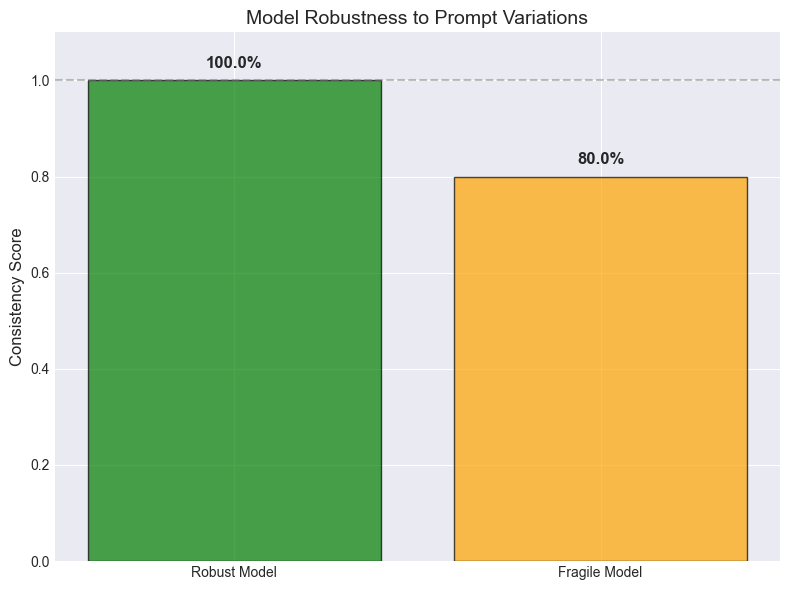

In [5]:
# Example: Testing robustness to prompt variations
def evaluate_robustness(model_responses, prompt_variants):
    """
    Evaluate how consistent model performance is across prompt variations
    """
    # Simulate model responses to different prompt phrasings
    # In practice, you'd query an actual model
    
    print("Robustness Testing: Prompt Variation Analysis")
    print("="*60)
    print("\nTask: Answer 'What is 2+2?'\n")
    
    for i, (prompt, response) in enumerate(zip(prompt_variants, model_responses), 1):
        print(f"Variant {i}: '{prompt}'")
        print(f"  → Response: {response}")
        print()
    
    # Calculate consistency
    correct_responses = [r for r in model_responses if '4' in r]
    consistency = len(correct_responses) / len(model_responses)
    
    print(f"Consistency: {consistency:.1%} ({len(correct_responses)}/{len(model_responses)} variants correct)")
    
    return consistency

# Example with different prompt phrasings
prompts = [
    "What is 2+2?",
    "Calculate 2 plus 2",
    "2+2=",
    "If I have 2 apples and get 2 more, how many do I have?",
    "Solve: 2+2"
]

# Simulate model responses (robust model)
responses_robust = ["4", "4", "4", "4 apples", "4"]

# Simulate responses (less robust model) 
responses_fragile = ["4", "4", "The answer is 4", "You would have several apples", "2+2=4"]

print("Robust Model:")
consistency_robust = evaluate_robustness(responses_robust, prompts)

print("\n" + "="*60 + "\n")

print("Fragile Model:")
consistency_fragile = evaluate_robustness(responses_fragile, prompts)

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
models = ['Robust Model', 'Fragile Model']
consistencies = [consistency_robust, consistency_fragile]
colors = ['green', 'orange']

bars = ax.bar(models, consistencies, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Consistency Score', fontsize=12)
ax.set_title('Model Robustness to Prompt Variations', fontsize=14)
ax.set_ylim([0, 1.1])
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

# Add value labels on bars
for bar, val in zip(bars, consistencies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
           f'{val:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Example: Evaluating Generative Models – The pass@k Metric

### Motivation
• For **code generation** or other *open-ended tasks*, a single output isn’t enough —  
  models can produce many candidate solutions.

• **pass@k** measures the probability that *at least one* of the top-$k$ generated samples  
  passes all tests (i.e., is correct).

### Formula
$$
\text{pass@k} = 1 - \frac{\binom{n - c}{k}}{\binom{n}{k}}
$$

where:  
- $n$ = total number of samples generated  
- $c$ = number of correct solutions  
- $k$ = number of samples considered  

### Interpretation
- **pass@1** → how often the *first* sample is correct (analogous to accuracy)  
- **pass@10** → chance that *any* of 10 attempts succeeds  
- Used in **OpenAI HumanEval**, **MBPP**, and similar benchmarks for code generation

pass@k Metric for Code Generation
Total samples generated: 100
Correct solutions: 40 (40%)

pass@  1 = 0.400 (40.0%)
pass@  5 = 0.927 (92.7%)
pass@ 10 = 0.996 (99.6%)
pass@ 25 = 1.000 (100.0%)
pass@ 50 = 1.000 (100.0%)
pass@100 = 1.000 (100.0%)


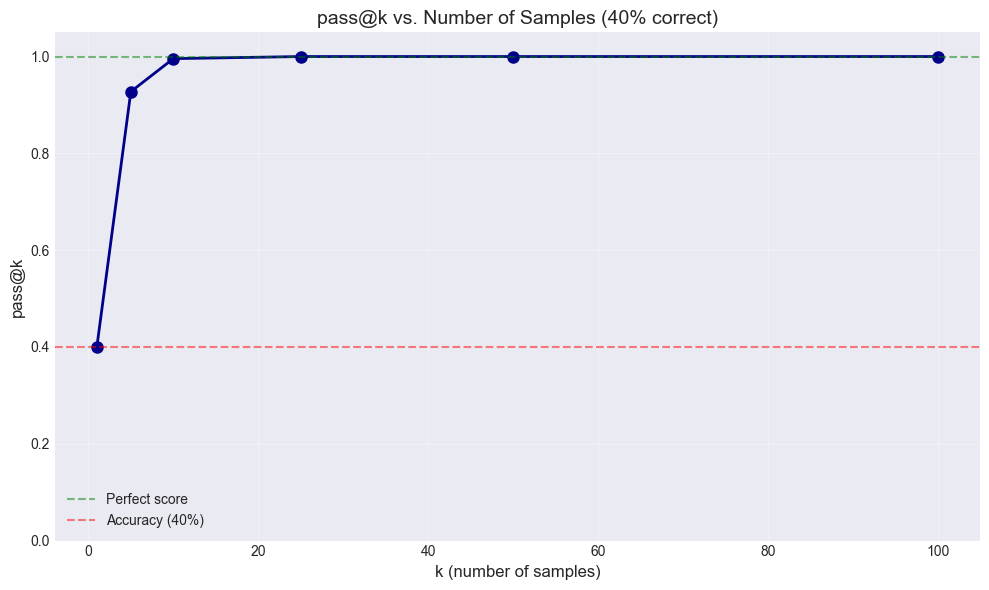


→ pass@k increases with k because we have more chances to get a correct solution


In [6]:
# Demonstrate pass@k calculation for code generation
from scipy.special import comb

def calculate_pass_at_k(n, c, k):
    """
    Calculate pass@k metric for code generation
    n: total number of samples generated
    c: number of samples that pass all tests
    k: number of samples to consider
    
    pass@k = E[1 - (n-c choose k) / (n choose k)]
         = probability that at least 1 of k samples is correct
    """
    if n - c < k:
        return 1.0
    return 1.0 - (comb(n - c, k) / comb(n, k))

# Example: Model generates 100 solutions, 40 are correct
n_samples = 100
n_correct = 40

print("pass@k Metric for Code Generation")
print("="*60)
print(f"Total samples generated: {n_samples}")
print(f"Correct solutions: {n_correct} ({n_correct/n_samples:.0%})")
print()

k_values = [1, 5, 10, 25, 50, 100]
pass_at_k_values = []

for k in k_values:
    if k <= n_samples:
        pass_k = calculate_pass_at_k(n_samples, n_correct, k)
        pass_at_k_values.append(pass_k)
        print(f"pass@{k:3d} = {pass_k:.3f} ({pass_k*100:.1f}%)")
    else:
        pass_at_k_values.append(None)

# Visualize
valid_k = [k for k, v in zip(k_values, pass_at_k_values) if v is not None]
valid_values = [v for v in pass_at_k_values if v is not None]

plt.figure(figsize=(10, 6))
plt.plot(valid_k, valid_values, 'o-', linewidth=2, markersize=8, color='darkblue')
plt.xlabel('k (number of samples)', fontsize=12)
plt.ylabel('pass@k', fontsize=12)
plt.title('pass@k vs. Number of Samples (40% correct)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.05])
plt.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Perfect score')
plt.axhline(y=n_correct/n_samples, color='red', linestyle='--', alpha=0.5, label='Accuracy (40%)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n→ pass@k increases with k because we have more chances to get a correct solution")

<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# B. Evaluation Frameworks and Benchmarks



# From Individual Evaluation to Community Frameworks

• As NLP matured, evaluation moved from **isolated experiments**  
  to **shared, standardized setups** that let researchers compare systems directly.

• These frameworks ensure:
  - **Reproducibility** — same data and metrics across papers  
  - **Comparability** — fair measurement of progress  
  - **Transparency** — public datasets and leaderboards  

• Early roots: **Message Understanding Conference (MUC)**, **TREC**  
  → later evolved into **SemEval**, **WMT**, and **Kaggle** challenges

> Shared evaluation frameworks transformed NLP from  
> *“my dataset, my metric”* → *community-wide measurement of progress.*


# Shared Tasks

• **What are Shared Tasks?**  
  - Community-organized evaluations where everyone trains on the same data  
    and submits predictions on a **hidden test set**  
  - Designed to ensure **fair comparison** and **reproducibility**  
  - Often accompanied by a workshop or leaderboard

• **Examples of Major Shared Tasks**
  - **WMT (Machine Translation):** Translate sentences between languages →  
    evaluated by BLEU / COMET scores
  - **SemEval (Semantic Evaluation):** Tasks like sentiment analysis,  
    textual entailment, or semantic similarity → evaluated by F1 / correlation
  - **CoNLL (Parsing):** Named entity recognition or dependency parsing →  
    evaluated by token-level F1 or LAS/UAS
  - **Kaggle:** Applied NLP competitions (e.g., toxic comment detection)

• **Takeaway**  
  - A *task* is a formalized abstraction of a broader *problem*  
  - It defines the **inputs**, **outputs**, and **metrics** that make comparison possible

> Shared tasks turn research questions into reproducible experiments —  
> but real understanding still requires thinking beyond the leaderboard.


# From Shared Tasks to Benchmarks

• Shared tasks evolve into **long-term benchmarks** that measure progress over time  
  – Same dataset, metrics, and test split reused across papers  
  – Enables longitudinal tracking of models (“SOTA”)  

• **Examples**
  - GLUE / SuperGLUE → General language understanding  
  - MMLU → Multidisciplinary reasoning (57 subjects)  
  - GSM8K → Math word problems  
  - HumanEval → Code generation correctness  

• **Takeaway**
Benchmarks are *institutionalized shared tasks* — they turn short-term competitions
into stable references for scientific progress.


<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c"
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# **C. Standard Benchmarks and Metrics**

### How do we measure progress in the state of the art NLP today?  


# Why Benchmarks?

• Benchmarks make NLP evaluation **comparable** and **reproducible**  
  – same dataset + split + metric across all models  

• They let us track **progress over time** and identify **model weaknesses**  

• Typical benchmark families  
  - Knowledge & Reasoning  
  - Math & Logic  
  - Code Generation  
  - Retrieval / Embedding  
  - Text Generation (MT / Summarization / Dialogue)

> Benchmarks are the *institutional memory* of NLP progress.


### Huggingface Open LLM leaderbaord

https://huggingface.co/spaces/open-llm-leaderboard/open_llm_leaderboard#/

# Knowledge & Reasoning Benchmarks

• **MMLU** – 57 subjects (STEM, Humanities, Law, Medicine)  
  → *Multiple-choice accuracy*  
  – Tests factual & reasoning breadth  

• **MMLU-Pro (2024)** – Harder variant, 4–10 options per question  

• **SuperGLUE** – Linguistic understanding benchmark  
  → Combines entailment, coreference, commonsense tasks  

• **HellaSwag** – Sentence-completion with adversarial distractors  
  → Measures *commonsense plausibility*

    Metric: simple accuracy on multiple-choice questions


# Knowledge & Reasoning Benchmarks

• **MMLU (Massive Multitask Language Understanding)**  
  – 57 subjects (STEM, humanities, law, medicine)  
  – **Format:** 4-choice multiple-choice questions  
  – **Metric:** accuracy (percentage correct)  

• **MMLU-Pro (2024)** — Harder successor with 4–10 options per question  


<div style="text-align:center; margin-top:10px;">
  <img src="img/mmlu_1.png" alt="Example MMLU question" style="max-width:60%; border:1px solid #ccc; margin:5px;">
  <img src="img/mmlu_2.png" alt="MMLU benchmark coverage" style="max-width:60%; border:1px solid #ccc; margin:5px;">
</div>




# SuperGLUE Tasks Explained

Each SuperGLUE subtask targets a **different aspect of language understanding**.
Together, they test reasoning, inference, and coreference — beyond simple pattern matching.

| **Task** | **What It Tests** | **Example Behavior** |
|:--|:--|:--|
| **BoolQ** | Yes/no *reading comprehension* | Read a passage and answer a factual question (e.g., “Is Barq’s root beer a Pepsi product?” → *No*) |
| **CB (CommitmentBank)** | *Textual entailment* with uncertain stance | Judge if a hypothesis follows from a conversational statement (*Entailment / Contradiction / Unknown*) |
| **COPA** | *Causal reasoning* | Choose which event best explains or results from another (“The grass was cut” → The sun was rising ✅) |
| **MultiRC** | *Multi-sentence reasoning* | Answer questions requiring aggregation across multiple sentences |
| **ReCoRD** | *Reading comprehension + commonsense inference* | Fill in missing entities from a passage (“Puerto Rico Gov. Ricardo Rossello said…” → Correct Entity = US) |
| **RTE** | *Recognizing textual entailment* | Determine whether one statement entails another (“Christopher Reeve had an accident” → False) |
| **WiC** | *Word sense disambiguation* | Decide if a target word has the same meaning in two contexts (“board” as noun vs verb → False) |
| **WSC** | *Coreference resolution / commonsense reasoning* | Identify pronoun reference in tricky cases (“He should have been more truthful.” → False) |



>**Takeaway:**  
> SuperGLUE decomposes “language understanding” into eight precise diagnostic tasks —  
> providing a composite view of a model’s linguistic and reasoning competence.


<div style="text-align:center; margin-top:10px;">
  <img src="img/superglue_wang.png" alt="Superglue Wang et al." style="max-width:100%; border:1px solid #ccc; margin:5px;">
</div>

Wang, Alex, et al. "Superglue: A stickier benchmark for general-purpose language understanding systems." 

# Commonsense & Contextual Reasoning – HellaSwag

• **HellaSwag (Zellers et al., ACL 2019)**  
  – Focuses on **commonsense reasoning** and **grounded continuation**  
  – Given a short premise (caption or event), the model must choose the most plausible continuation among 4 candidates  
  – Options are *adversarially filtered* — superficially similar but semantically incorrect  
  – **Metric:** multiple-choice accuracy  

Example:
> *Premise:* “A woman is putting a baby into the crib…”  
> *Options:*  
> A) She closes the crib and turns off the light ✅  
> B) She lifts the baby and begins a dance performance  
> C) The baby walks out of the house  
> D) The woman paints a wall  

→ Tests whether the model understands everyday physical and social events.


## HellaSwag-Pro (2024)
• Harder variant for **large language models**, with longer contexts and distractors designed to fool instruction-tuned models  
• Includes more *fine-grained entailment* and multi-sentence reasoning  
• **Metric:** same multiple-choice accuracy (but substantially lower for most models)

<div style="text-align:center; margin-top:10px;">
  <img src="img/helloswag_pro.png" alt="HellaSwag-Pro benchmark coverage" style="max-width:70%; border:1px solid #ccc; margin:5px;">
</div>

*Visualization: HellaSwag-Pro introduces richer context and harder distractors — accuracy drops even for GPT-4–class models.*

> HellaSwag and its “Pro” version test *commonsense plausibility* rather than factual recall —  
> a key complement to knowledge benchmarks like MMLU.

# Math Reasoning Benchmarks

• **GSM8K (Cobbe et al., 2021)**  
  – 8.5 k grade-school math word problems  
  – Each requires **multi-step arithmetic reasoning**  
  – **Input:** natural-language problem  
  – **Output:** final numeric answer  
  – **Metric:** Exact Match (EM) — does the predicted final answer exactly match the ground truth?  

• **MATH (Hendrycks et al., 2021)**  
  – Harder dataset from AMC & Olympiad-level problems  
  – Covers algebra → geometry → probability  
  – Evaluated with **Exact Match**, sometimes per-topic breakdown  

### Example (GSM8K)
> *Question:*  
> Janet’s ducks lay 16 eggs per day. She eats 3 for breakfast and uses 4 to bake muffins. She sells the rest for \$2 each.   
> How much does she make per day?

**Reasoning (Chain of Thought):**  
1. Total eggs = 16  
2. Eggs used = 3 + 4 = 7  
3. Eggs sold = 16 − 7 = 9  
4. Revenue = 9 × 2 = \$18  

**Final Answer:** 18  
**Metric:** Exact Match = ✔ (correct)


In [10]:
import re
from datasets import load_dataset

# Load GSM8K test split (small sample for demonstration)
gsm8k = load_dataset("gsm8k", "main", split="test[:5]")

# Simulated model predictions (in practice, generated by your LLM)
model_outputs = [
    "Let's compute: 16 - (3 + 4) = 9; 9 * 2 = 18. #### 18",
    "She eats 3 and gives 4 to friends. 16 - 7 = 9. 9 * 2 = 18. #### 18",
    "16 eggs, uses 7, sells 9 each $2. Total $18. #### 18",
    "16 - 3 - 4 = 9, sells for $2 → 18. #### 18",
    "She makes $16 * 2 = 32. #### 32"
]

# Extract numeric predictions
def extract_number(text):
    match = re.search(r"####\s*([\d\.\-]+)", text)
    return match.group(1) if match else None

preds = [extract_number(t) for t in model_outputs]
refs  = [ex["answer"].split("####")[-1].strip() for ex in gsm8k]

# Compute Exact Match (EM)
correct = sum(p == r for p, r in zip(preds, refs))
em = correct / len(refs)

print(f"Exact Match (EM): {em:.2%}")


Generating test split: 100%|█████████████████████████████████████████████████████████████████████████████████| 1319/1319 [00:00<00:00, 612927.87 examples/s]

Exact Match (EM): 20.00%


In [12]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch, re

model_name = "microsoft/phi-2"  # 2.7B parameter model, small but reasoning-capable
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16).to("cuda" if torch.cuda.is_available() else "cpu")

def ask(question):
    prompt = f"""Solve the following problem step by step and give the final answer as '#### <number>'.

Example:
Q: Tom has 3 apples and buys 2 more. How many apples does he have?
A: Let's add them: 3 + 2 = 5. #### 5

Now solve this:
Q: {question}
A:"""
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    out = model.generate(**inputs, max_new_tokens=100)
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    match = re.search(r"####\s*([\d\-\.]+)", text)
    return text, match.group(1) if match else None

question = "Janet’s ducks lay 16 eggs per day. She eats 3 for breakfast and uses 4 to bake muffins. She sells the rest for $2 each. How much does she make per day?"
full, ans = ask(question)
print(full)
print(f"\nExtracted answer: {ans}")


`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 10.75it/s]
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Solve the following problem step by step and give the final answer as '#### <number>'.

Example:
Q: Tom has 3 apples and buys 2 more. How many apples does he have?
A: Let's add them: 3 + 2 = 5. #### 5

Now solve this:
Q: Janet’s ducks lay 16 eggs per day. She eats 3 for breakfast and uses 4 to bake muffins. She sells the rest for $2 each. How much does she make per day?
A:!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Extracted answer: 5


# Code Generation Benchmarks

• **HumanEval (Chen et al., 2021)**  
  – 164 Python programming problems  
  – **Input:** function signature + docstring  
  – **Output:** valid Python implementation  
  – **Metric:** $pass@k$ — probability that at least one of the $k$ generated programs passes all unit tests  

• **MBPP (Austin et al., 2021)**  
  – “Mostly Basic Python Problems” for simpler coding skills  
  – Also uses test-based evaluation rather than string matching  

• **SWE-bench (Jimenez et al., 2024)**  
  – End-to-end software-engineering tasks on real GitHub repositories  
  – Model must edit code to fix a bug or implement a feature  
  – Evaluated by whether all unit tests pass after the patch  



### Example (HumanEval)
> *Prompt:*  
> ```python
> def has_close_elements(numbers: list[float], threshold: float) -> bool:
>     """Check if any two numbers are closer than the given threshold."""
> ```
> Model generates several candidate implementations.  
> Each is executed against unit tests, and $pass@k$ is computed.

**Takeaway:**  
Code-generation benchmarks measure *functional correctness*, not surface similarity.  
Metrics like $pass@k$ reflect stochastic diversity — higher $k$ means a greater chance of success.

# Retrieval and Embedding Benchmarks

• **BEIR (Thakur et al., 2021)**  
  – Benchmark for zero-shot document retrieval  
  – Includes 18 datasets across diverse domains  
    (news, Wikipedia, QA, biomedical, scientific, web)  
  – Evaluates how well sentence or document embeddings support retrieval  
  – **Metrics:** nDCG@k, Recall@k

• **MTEB (Massive Text Embedding Benchmark, Muennighoff et al., 2023)**  
  – Unified framework for evaluating text embeddings  
  – Covers 8 task categories:  
    STS, classification, clustering, reranking, retrieval, bitext mining, summarization, pair classification  
  – **Metrics:** accuracy, F1, or Spearman $\rho$, depending on task



# Metrics for Retrieval and Embedding Evaluation

### 1. nDCG@k — Normalized Discounted Cumulative Gain
Used in retrieval tasks (e.g., BEIR) to measure *ranking quality*.

$DCG@k = \sum_{i=1}^{k} \dfrac{rel_i}{\log_2(i + 1)}$
 where $rel_i$ is the relevance score of the document at rank $i$.

$ nDCG@k = \dfrac{DCG@k}{IDCG@k} $

**Example**

| Rank | Document | Human Relevance Score | Comment |
|:----:|:---------:|:--------------------:|:--------|
| 1 | Doc A | 3 | Highly relevant |
| 2 | Doc B | 2 | Somewhat relevant |
| 3 | Doc C | 0 | Not relevant |

Ideal ranking (ground truth): [3, 2, 0]  
System ranking (perfect): [3, 2, 0] → $nDCG@3 = 1.0$

If the system ranked [2, 0, 3] instead:  
$DCG@3 = 2/1 + 0/\log_2(3) + 3/\log_2(4) = 3.5$  
$IDCG@3 = 4.26 \Rightarrow nDCG@3 = 0.82$

→ Higher $nDCG@k$ means relevant items appear earlier in the ranking.

### 2. Spearman ρ — Rank Correlation
Used in embedding evaluation (e.g., MTEB) to measure how well  
model similarity rankings agree with human similarity judgments.

$\rho = 1 - \dfrac{6 \sum d_i^2}{n(n^2 - 1)}$

**Example**

| Pair | Human Rank | Model Rank | $d_i$ | $d_i^2$ |
|:--:|:--:|:--:|:--:|:--:|
| 1 | 1 | 1 | 0 | 0 |
| 2 | 2 | 3 | 1 | 1 |
| 3 | 3 | 2 | –1 | 1 |
| 4 | 4 | 5 | 1 | 1 |
| 5 | 5 | 4 | –1 | 1 |

$\sum d_i^2 = 4$, $n = 5$  
$\rho = 1 - \dfrac{6 × 4}{5 (25 − 1)} = 0.8$

→ $\rho = 0.8$ means strong agreement between model and human judgments.

---

**Takeaway**  
- $nDCG@k$ evaluates ranking order for retrieval.  
- $\rho$ measures rank agreement for embeddings.  
Together they capture how well models encode and retrieve meaning.

# Machine Translation Benchmark — WMT

### Overview
- **Workshop on Machine Translation (WMT)** — annual shared task since 2005  
- Evaluates *translation quality* across many language pairs  
- Combines **automatic** (BLEU, COMET) and **human** evaluation  
- Tests both fluency and semantic adequacy

---

### BLEU Metric

$ BLEU = BP \times \exp\left( \sum_{n=1}^{N} w_n \log p_n \right) $

Where:
- $p_n$ = modified n-gram precision  
- $BP$ = brevity penalty  
- $w_n$ = uniform weights (e.g. 0.25 for 1–4-grams)


**Example**

Reference: “the cat is on the mat”  
Candidate: “the cat sat on mat”  
→ Overlaps on 4 out of 6 unigrams → BLEU ≈ 0.67

**Interpretation:**  
Higher BLEU → more lexical overlap, but doesn’t capture meaning differences.

---

**Takeaway**  
BLEU provides quick reproducible comparison,  
but newer metrics (e.g. COMET) better capture semantic quality.

# COMET — Crosslingual Optimized Metric for Evaluation of Translation

### Why BLEU Falls Short for MT
BLEU treats *any* deviation from the reference as an error —
it cannot distinguish a fluent but meaning-altering translation from a minor rewording.

### How COMET Works
COMET is a **learned neural metric** trained to predict human quality judgments (MQM scores).

1. **Encoder** — a multilingual pretrained LM (XLM-R) encodes **three** inputs separately:
   - Source sentence $s$
   - Hypothesis (system output) $h$
   - Reference translation $r$
2. **Aggregation** — sentence embeddings are combined (concatenation + element-wise product & difference)
3. **Regression head** — predicts a scalar quality score

**Key advantage over BLEU:**  
COMET uses the **source sentence** — it can detect when a translation is fluent but
diverges from what the source actually says. BLEU has no access to the source.

---

### COMET Variants (2024)

| Model | Type | Description |
|:--|:--|:--|
| `wmt22-comet-da` | Reference-based | Standard COMET, trained on Direct Assessment scores |
| `wmt22-cometkiwi-da` | Reference-free (QE) | Uses only source + hypothesis — no reference needed |
| **XCOMET-XL** | Reference-based + error spans | Identifies error spans with MQM severity labels |

### Example

| System | BLEU | COMET |
|:--|:--|:--|
| Translation A (fluent but wrong meaning) | 28.4 | 0.42 |
| Translation B (slightly awkward but faithful) | 19.1 | 0.79 |

→ COMET ranks Translation B higher — correctly matching human preference.  
→ BLEU ranks Translation A higher — rewarding surface overlap over semantic adequacy.

**Takeaway:**  
COMET is the current gold standard for MT evaluation at WMT, replacing BLEU as the primary metric.  
It correlates substantially better with human MQM judgments than any n-gram–based metric.

<sub>Rei et al. (2020). "COMET: A Neural Framework for MT Evaluation." EMNLP 2020.</sub>


# ROUGE — Recall-Oriented Understudy for Gisting Evaluation

### Purpose
ROUGE evaluates *content coverage* between a generated summary and a human reference.
It measures **recall** — how much of the reference information appears in the system output.

---

### Core Variants
- **ROUGE-N**: n-gram overlap (ROUGE-1 = unigrams, ROUGE-2 = bigrams)  
- **ROUGE-L**: longest common subsequence (sentence-level structure)  
- **ROUGE-W**: weighted LCS (favors consecutive matches)

$ ROUGE\text{-}N = 
\frac{ \sum_{S \in \text{Refs}} \sum_{gram_n \in S} Count_{match}(gram_n) }
{ \sum_{S \in \text{Refs}} \sum_{gram_n \in S} Count(gram_n) } $

---

### Example

| Type | Reference | Candidate | Overlap | Score |
|:----|:-----------|:-----------|:--------|:------|
| ROUGE-1 | “the brown fox jumps” | “the fox jumps quickly” | the, fox, jumps | 3 / 4 = 0.75 |
| ROUGE-2 | “brown fox, fox jumps” | “the fox, fox jumps” | fox jumps | 1 / 2 = 0.50 |

---

### Interpretation
- ROUGE-N measures how much *reference content* is recalled  
- High ROUGE = good coverage but not necessarily faithful wording  
- Ignores paraphrasing and factual correctness

**Takeaway:**  
BLEU → *precision-based lexical overlap*  
ROUGE → *recall-based content overlap*  
Together they form the foundation for evaluating machine translation and summarization.


# XSum — Extreme Summarization

### Overview
- **XSum (BBC Extreme Summarization Corpus)**  
  Each article → **one-sentence summary** capturing the *central event* or *fact*.
- Designed to test:
  - **Abstraction:** generate new phrasing, not copy text
  - **Compression:** condense entire article into a single sentence
  - **Factual grounding:** maintain key information accurately

---

### Evaluation Metric — ROUGE

ROUGE compares *n-gram overlap* between system output and human reference.

$ ROUGE\text{-}N =
\frac{ \sum_{S \in \text{Refs}} \sum_{gram_n \in S} Count_{match}(gram_n) }
{ \sum_{S \in \text{Refs}} \sum_{gram_n \in S} Count(gram_n) } $

- **ROUGE-1:** unigram recall (word coverage)  
- **ROUGE-2:** bigram recall (phrase consistency)  
- **ROUGE-L:** longest common subsequence (sentence structure)



### Example

| Type | Reference | Candidate | Overlap | Score |
|:----|:-----------|:-----------|:--------|:------|
| ROUGE-1 | “UK votes to leave EU” | “Britain leaves European Union” | leaves, EU | 2/4 = 0.50 |
| ROUGE-2 | “votes to, to leave, leave EU” | “Britain leaves, leaves European, European Union” | leave EU | 1/3 = 0.33 |

ROUGE ≈ 0.5 → partial lexical match  
But semantically correct even if words differ (“Britain” vs “UK”).

---

### Limitations of ROUGE in XSum

- High ROUGE doesn’t guarantee factual accuracy  
  (“EU votes to leave UK” would score similarly!)  
- Penalizes valid paraphrases
- Ignores entity substitutions and hallucinations

---

### Beyond ROUGE
Modern XSum evaluations include:
- **BERTScore:** contextual embedding similarity  
- **FactCC / QAFactEval:** factual consistency checks  
- **LLM-as-Judge:** GPT-4 rating on faithfulness, coherence, and coverage

---

**Takeaway**  
XSum tests *extreme abstraction and factual precision* —  
making it a far harder summarization benchmark than CNN/DailyMail or Gigaword.


# BERTScore — Contextual Embedding Evaluation

### Motivation
BLEU penalizes *any* word that doesn't appear in the reference — it treats
"automobile" and "car" as completely different.  
**BERTScore** uses contextual BERT representations, so semantically similar words
score nearly identically.

---

### How It Works

**Step 1 — Embed both sentences** with a pretrained model (e.g., `roberta-large`).  
Each token gets a **contextual vector** — its meaning in that specific sentence.

**Step 2 — Greedy matching** via cosine similarity:

$$P_{\text{BERT}} = \frac{1}{|\hat{y}|} \sum_{\hat{y}_i \in \hat{y}} \max_{y_j \in y} \cos(\hat{y}_i,\, y_j)$$

$$R_{\text{BERT}} = \frac{1}{|y|} \sum_{y_j \in y} \max_{\hat{y}_i \in \hat{y}} \cos(\hat{y}_i,\, y_j)$$

$$F_{\text{BERT}} = 2 \cdot \frac{P_{\text{BERT}} \cdot R_{\text{BERT}}}{P_{\text{BERT}} + R_{\text{BERT}}}$$

Where $\hat{y}$ = candidate tokens, $y$ = reference tokens.

**Step 3 — IDF weighting (optional):** Rare, informative tokens are upweighted;
common function words ("the", "a") contribute less.

---

### Example

| Candidate | Reference | BLEU | BERTScore-F1 |
|:--|:--|:--|:--|
| "The car drove fast." | "The automobile sped quickly." | 0.13 | 0.94 |
| "A dog chased the ball." | "The automobile sped quickly." | 0.08 | 0.61 |

→ BERTScore correctly identifies the first paraphrase as high-quality.

---

### Strengths and Limitations

| | BLEU | BERTScore |
|:--|:--|:--|
| Handles synonyms | ✗ | ✓ |
| Handles paraphrases | ✗ | ✓ |
| Computationally cheap | ✓ | ✗ |
| Interpretable score | ✓ (0–1 precision) | Partial (backbone-dependent) |
| Reference-free option | ✗ | ✗ |

**Takeaway:**  
BERTScore is a stronger automatic metric than BLEU/ROUGE for tasks involving paraphrase
or varied wording — used widely for summarization and dialogue evaluation.

<sub>Zhang et al. (2020). "BERTScore: Evaluating Text Generation with BERT." ICLR 2020. arXiv:1904.09675</sub>


In [ ]:
# BERTScore demo
import subprocess, sys

# Install bert_score if not already available
try:
    from bert_score import score as bert_score
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "bert_score", "-q"])
    from bert_score import score as bert_score

candidates = [
    "The automobile drove at high speed.",   # synonym of reference
    "A dog chased the ball.",                 # unrelated
    "The car moved quickly down the road.",   # close paraphrase
]
references = [
    "The car drove at high speed.",
    "The car drove at high speed.",
    "The car drove at high speed.",
]

# Compute BERTScore (using distilbert for speed; roberta-large is standard)
P, R, F1 = bert_score(candidates, references, lang="en",
                      model_type="distilbert-base-uncased", verbose=False)

# Rough unigram precision for comparison
def bleu1(cand, ref):
    c_words = set(cand.lower().split())
    r_words = set(ref.lower().split())
    return len(c_words & r_words) / len(c_words)

print(f"{'Candidate':<45} {'BLEU-1':>8} {'BERTScore F1':>14}")
print("-" * 70)
for cand, ref, f1 in zip(candidates, references, F1.tolist()):
    b = bleu1(cand, ref)
    print(f"{cand:<45} {b:>8.3f} {f1:>14.3f}")

print()
print("→ BERTScore ranks the synonym paraphrase higher than BLEU-1 does.")
print("  It captures semantic similarity that n-gram overlap misses.")


<div style="text-align:center; margin-top:10px;">
  <img src="img/ai_benchmark_progress.png" alt="AI benchmark progress" style="max-width:80%; border:1px solid #ccc; margin:5px;">
  
</div>

# Benchmark Contamination — A Critical Problem

### What Is Benchmark Contamination?

Benchmark contamination (also called **data contamination** or **train-test overlap**)
occurs when examples from a benchmark's **test set appear in a model's pretraining data**.

Because web-scraped corpora are enormous and unfiltered, many popular benchmarks
have had their questions appear on internet pages, forums, homework-help sites, and GitHub.

**Types of contamination:**
- **Direct** — the exact question-answer pair is in training data
- **Near-duplicate** — paraphrased versions appear in training data
- **Partial** — the answer is in training data even if the question phrasing differs

---

### Why It Is Systemic

1. **Training data opacity** — most frontier models do not publish training data, so
   external contamination auditing is impossible
2. **Incentive misalignment** — labs benefit from high benchmark scores
3. **No consistent standard** — different labs use different overlap-detection thresholds
4. **Benchmark saturation may be artificial** — some apparent "rapid progress" may reflect
   memorization rather than genuine capability improvement

---

### Evidence

- Masking a wrong answer choice in an MCQ and asking the model to fill it in ("slot guessing"):
  GPT-4 achieves **57% exact match** on MMLU option text — far above the 25% chance baseline
  → indicating memorization of specific answer strings
- Removing contaminated examples from GSM8K evaluation drops model accuracy by up to **13%**
  for some models
- Models trained after AIME 2024 problems circulated online score significantly higher
  than expected, while post-cutoff AIME 2025 scores drop substantially

<sub>Golchin & Surdeanu (2023). "Investigating Data Contamination in Modern Benchmarks." arXiv:2311.09783  
Yang et al. (2024). "Benchmark Data Contamination of Large Language Models: A Survey." arXiv:2406.04244</sub>


# Addressing Contamination: Detection and Live Benchmarks

### Detection Methods

| Method | How It Works |
|:--|:--|
| **Slot guessing** | Mask an answer option; if model fills it exactly, it likely memorized it |
| **Min-k% Prob** | High model probability on n-grams → likely in training data (Shi et al. 2024) |
| **Temporal analysis** | Evaluate on problems released *after* model training cutoff |
| **Canary injection** | Embed unique strings in eval sets; check if model can complete them |

---

### Live / Dynamic Benchmarks — The Solution

The answer to contamination is **continuously updated benchmarks** using newly generated content.

| Benchmark | Design | Why Contamination-Free |
|:--|:--|:--|
| **LiveBench** (2024) | Monthly problems from recent arXiv, news, IMDb, contests | Questions released *after* any training cutoff |
| **LiveCodeBench** (2024) | Programming problems from LeetCode/Codeforces with timestamps | Evaluated on problems released *after* model cutoff |
| **MathArena** (2025) | AIME problems released after model training | Real-time post-cutoff evaluation |

---

### Benchmark Saturation Timeline

| Benchmark | Year Released | Year ~Saturated |
|:--|:--|:--|
| HellaSwag | 2019 | 2021 |
| SuperGLUE | 2019 | 2022 |
| MMLU | 2020 | 2024 |
| GSM8K | 2021 | 2024 |
| HumanEval | 2021 | 2024–25 |

→ Each benchmark lasts ~2–3 years before top models exceed meaningful discrimination thresholds.  
The community has responded with progressively harder successors: MMLU-Pro, GPQA, Humanity's Last Exam.

---

**Takeaway:**  
A benchmark score is only meaningful if you know (a) whether training data was audited,
(b) the model's training cutoff vs. the benchmark release date, and (c) whether
live/contamination-free evaluation was performed.


<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c"
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# **D. Human evaluation vs LLM as a judge**



# Why Human Evaluation?

Automatic metrics (BLEU, ROUGE, COMET) can’t judge:
- Factual correctness  
- Coherence across sentences  
- Stylistic quality or nuance

→ We still rely on **human judgment** as the gold standard.


# Human Evaluation: Common Methods

| Method | What Annotators Do | Used For |
|:--|:--|:--|
| **Likert Scales** | Rate quality on 1–5 or 1–7 | Summarization, dialogue |
| **Pairwise Comparison** | Choose the better output | MT, chatbot responses |
| **Ranking** | Order several outputs | Multi-model studies |

**Example Criteria**
- *Fluency*: grammatical, natural wording  
- *Faithfulness*: preserves meaning  
- *Coherence*: logical flow


# Inter-Annotator Agreement — Validating Human Evaluation

### The Problem: Who Judges the Judges?

Before using human judgments as ground truth, we must ask:
**do different human annotators *agree* on the labels?**

If two annotators disagree 40% of the time on sentiment labels, those labels
are not reliable ground truth — they are noisy approximations.
Poor IAA propagates into model training, benchmark construction, and RLHF preference data.

---

### Cohen's Kappa — The Standard Measure

Cohen's $\kappa$ measures **agreement beyond chance** between two raters:

$$\kappa = \frac{P_o - P_e}{1 - P_e}$$

Where:
- $P_o$ = **observed** agreement (fraction of items both annotators labeled identically)
- $P_e$ = **expected** agreement by chance (computed from marginal label distributions)

**Interpretation:**

| $\kappa$ | Agreement |
|:--:|:--|
| < 0.00 | Less than chance |
| 0.00 – 0.20 | Slight |
| 0.21 – 0.40 | Fair |
| 0.41 – 0.60 | Moderate |
| 0.61 – 0.80 | **Substantial** ← target for NLP annotation |
| 0.81 – 1.00 | Near-perfect |

---

### Example

Two annotators label 100 sentences as Positive / Negative:

| | Annotator B: Positive | Annotator B: Negative | Row Total |
|:--|:--:|:--:|:--:|
| **Annotator A: Positive** | 40 | 10 | 50 |
| **Annotator A: Negative** | 15 | 35 | 50 |
| **Col Total** | 55 | 45 | 100 |

$P_o = (40 + 35)/100 = 0.75$  
$P_e = (50/100)(55/100) + (50/100)(45/100) = 0.275 + 0.225 = 0.50$  
$\kappa = (0.75 - 0.50) / (1 - 0.50) = 0.50$ → **Moderate agreement**

---

### IAA in Practice

- **Toxicity benchmarks** (e.g., Jigsaw): $\kappa$ often < 0.40 — toxicity is subjective and culturally variable
- **SQuAD 2.0** (extractive QA): $\kappa$ typically > 0.80 — task is well-constrained
- **RLHF preference data**: if annotators agree ~70% of the time on a binary task,
  $\kappa \approx 0.40$ (fair) — raising serious questions about reward model reliability

**For multiple raters:** use **Fleiss' Kappa**; for ordinal categories: **Weighted Kappa** or **Krippendorff's Alpha**.

> When evaluating a paper's human evaluation, always ask: *what is the IAA?*  
> If unreported, treat the human evaluation with skepticism.


# LLM-as-a-Judge

### Idea
Use a strong LLM (e.g., GPT-4, Claude) to act as an evaluator.

### Process
1. Give prompt + outputs + rubric  
2. Ask model to rate or compare  
3. Aggregate scores across samples

### Benefits
- Fast and consistent  
- Correlates highly with humans ($r > 0.8$)  
- Scales to thousands of examples

### Caution
- May prefer its own “style”  
- Verbosity bias → longer = higher score


# Benchmarks Using LLM-as-Judge

### Chatbot Arena
- Real users compare two anonymous chatbots  
- Votes → **Elo ratings** (like chess)  
- Blind, large-scale, preference-based

### MT-Bench
- Structured multi-turn QA and reasoning  
- GPT-4 acts as automatic judge  
- Scores 1–10 on faithfulness, coherence, helpfulness

**Takeaway:**  
Evaluation is moving from fixed metrics → human preference → **LLM-based judgment** at scale.


# LLM-as-a-Judge: Known Biases and Mitigation

### The Problem

LLM judges are fast and scalable — but they carry **systematic biases**
documented across multiple 2024 papers. Using an LLM judge *naively* can
produce misleading evaluation results.

---

### Documented Biases

| Bias | What Happens | Example |
|:--|:--|:--|
| **Position Bias** | Judge prefers response placed *first* (or last) in a pair, regardless of quality | Swap A and B → ranking reverses for ~25% of pairs |
| **Verbosity Bias** | Longer responses score higher even when length adds no quality | A 500-word answer beats a 150-word answer on the same question |
| **Self-Preference Bias** | GPT-4 prefers GPT-4-style outputs; Claude prefers Claude-style outputs | Evaluating Claude vs GPT-4 with GPT-4 as judge systematically favors GPT-4 |
| **Sycophancy / Authority Bias** | Judge changes score if told "an expert preferred the other answer" | Model capitulates to stated authority rather than maintaining independent judgment |

---

### Practical Mitigation

| Mitigation | How It Helps |
|:--|:--|
| **Randomize presentation order** and average both orderings | Cancels position bias |
| **Length-controlled scoring** (e.g., AlpacaEval 2 LC) | Fits a regression controlling for length difference; raises Spearman ρ with human votes from 0.94 → 0.98 |
| **Swap-consistency check** | Flag pairs where judge reverses ranking on swap |
| **Multi-judge averaging** | Use 2–3 different LLMs and average to reduce self-preference |
| **Spot-check with humans** | Validate 5–10% of LLM judgments manually to detect systematic errors |

---

### Chatbot Arena: Crowdsourced Evaluation Caveats

Chatbot Arena (LMSYS) uses real-user blind comparisons, which largely avoids
automated judge biases — but introduces **crowdsourced biases**:
- Convenience sampling: users who voluntarily participate are not representative
- Recency bias: newer models get more traffic, inflating their Elo
- **Vote rigging**: a 2025 paper demonstrated coordinated voting can shift Elo by tens of points

---

**Takeaway:**  
LLM-as-judge is a valuable tool, but **always report** which judge was used,
whether position was randomized, and whether length-controlled scoring was applied.
Never treat LLM judge scores as equivalent to human evaluation without validation.

<sub>Zheng et al. (2024). "Judging LLM-as-a-Judge with MT-Bench and Chatbot Arena."  
Park et al. (2024). "Offsetbias: Capitalizing on Calibrating the LLM-as-Judge." arXiv:2410.21819  
Dubois et al. (2024). "Length-Controlled AlpacaEval." arXiv:2404.04475</sub>
